# Section 3 — Construction du Dataset de Décisions

**Fichier source** : `build_decision_dataset.py`

---

## L'idée centrale : l'apprentissage par imitation

L'oracle OR-Tools nous donne des **tournées complètes** : `[[3,1,7], [4,6], [2,5,8,9,10]]`.

Mais le modèle doit prendre des **décisions une par une** — à chaque étape, choisir le prochain client à visiter. On doit donc **rejouer** chaque tournée oracle pas à pas et capturer chaque décision individuelle :

```
Tournée oracle : [0 → 3 → 1 → 7 → 0]

Décision 1 : je suis au dépôt (0), l'oracle choisit → client 3
Décision 2 : je suis au client 3, l'oracle choisit → client 1
Décision 3 : je suis au client 1, l'oracle choisit → client 7
Décision 4 : je suis au client 7, l'oracle choisit → dépôt (0)
```

Chaque décision devient **un exemple d'entraînement** : état actuel + label = nœud choisi par l'oracle.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from preprocess import generate_instance, preprocess
from oracle import resoudre_instance
from build_decision_dataset import (
    ReplayState,
    compute_static_node_features,
    compute_feasible_action_mask,
    build_decision_example,
    advance_state_with_target,
    extract_decision_examples_from_solution,
    build_decision_dataset,
    save_decision_dataset,
    load_decision_dataset,
    summarize_decision_dataset,
)

SEED = 42
N    = 10
instance = generate_instance(n=N, seed=SEED)
sol      = resoudre_instance(instance, time_limit_s=5.0)

print(f"Instance n={N}, seed={SEED}")
print(f"Solution oracle : {[r for r in sol['tournees'] if r]}")
print(f"Coût oracle     : {sol['cout']:.2f}")

Instance n=10, seed=42
Solution oracle : [[7, 6, 3, 5], [1, 10, 2, 4], [8, 9]]
Coût oracle     : 381.63


## 1. L'état courant — `ReplayState`

À chaque instant du rejeu, on maintient un objet `ReplayState` qui représente la situation du véhicule :

```python
@dataclass
class ReplayState:
    current_node   : int        # nœud où se trouve le véhicule
    current_time   : float      # temps écoulé depuis le début
    current_load   : float      # charge accumulée dans le véhicule
    served_global  : Set[int]   # tous les clients déjà servis (tous véhicules)
    served_in_route: List[int]  # clients servis sur la route courante
```

L'état est mis à jour à chaque décision via `advance_state_with_target()`.

In [13]:
# État initial : véhicule 1 au dépôt
state = ReplayState(
    current_node=0,
    current_time=0.0,
    current_load=0.0,
    served_global=set(),
    served_in_route=[],
)
print("État initial :")
print(f"  Nœud courant   : {state.current_node} (dépôt)")
print(f"  Temps courant  : {state.current_time:.1f} min")
print(f"  Charge courante: {state.current_load:.1f}")
print(f"  Clients servis : {state.served_global}")

# On avance vers le premier client de la première route
premiere_route = [r for r in sol['tournees'] if r][0]
cible = premiere_route[0]
print(f"\nL'oracle choisit : client {cible}")

state2 = advance_state_with_target(instance, state, cible)
print(f"\nÉtat après la décision :")
print(f"  Nœud courant   : {state2.current_node}")
print(f"  Temps courant  : {state2.current_time:.2f} min")
print(f"  Charge courante: {state2.current_load:.1f}  (demande client {cible} = {instance['demands'][cible]:.0f})")
print(f"  Clients servis : {state2.served_global}")

État initial :
  Nœud courant   : 0 (dépôt)
  Temps courant  : 0.0 min
  Charge courante: 0.0
  Clients servis : set()

L'oracle choisit : client 7

État après la décision :
  Nœud courant   : 7
  Temps courant  : 47.40 min
  Charge courante: 14.0  (demande client 7 = 14)
  Clients servis : {7}


### Détail : que fait `advance_state_with_target()` ?

Cette fonction fait **avancer l'horloge** du véhicule selon les règles VRPTW :

```
nouveau_temps = max(arrivée, a_i)   ← attente si on arrive trop tôt
               (arrivée = temps_courant + service_courant + trajet)

nouvelle_charge = charge_courante + demande_client
```

Trace complète d'une route :

In [14]:
premiere_route = [r for r in sol['tournees'] if r][0]
chemin = [0] + premiere_route + [0]

print(f"Route oracle : {chemin}")
print()
print(f"{'Étape':>5} | {'De':>5} | {'Vers':>5} | {'Trajet':>8} | {'Service':>8} | {'Arrivée':>8} | {'TW client':>14} | {'Début svc':>10} | {'Charge':>7}")
print("─" * 95)

s = ReplayState(current_node=0, current_time=0.0, current_load=0.0,
                served_global=set(), served_in_route=[])

for step, (a, b) in enumerate(zip(chemin[:-1], chemin[1:])):
    trajet  = instance['durees'][a, b]
    service = instance['service_times'][a]
    arrivee = s.current_time + service + trajet
    tw_b    = instance['time_windows'][b]
    debut   = max(arrivee, tw_b[0])
    demande = instance['demands'][b]
    tw_str  = f"[{tw_b[0]:.0f}, {tw_b[1]:.0f}]"

    print(f"{step+1:>5} | {a:>5} | {b:>5} | {trajet:>8.1f} | {service:>8.1f} | {arrivee:>8.1f} | {tw_str:>14} | {debut:>10.1f} | {s.current_load+demande:>7.1f}")

    if b != 0:
        s = advance_state_with_target(instance, s, b)

Route oracle : [0, 7, 6, 3, 5, 0]

Étape |    De |  Vers |   Trajet |  Service |  Arrivée |      TW client |  Début svc |  Charge
───────────────────────────────────────────────────────────────────────────────────────────────
    1 |     0 |     7 |     21.2 |      0.0 |     21.2 |      [47, 304] |       47.4 |    14.0
    2 |     7 |     6 |     17.5 |     14.7 |     79.6 |     [166, 303] |      166.2 |    44.0
    3 |     6 |     3 |     16.9 |     12.4 |    195.5 |     [105, 204] |      195.5 |    66.0
    4 |     3 |     5 |     31.6 |      5.4 |    232.5 |     [245, 375] |      245.2 |    69.0
    5 |     5 |     0 |     22.5 |     11.8 |    279.5 |       [0, 480] |      279.5 |    69.0


## 2. Le masque d'actions faisables — `compute_feasible_action_mask()`

À chaque étape, **tous les nœuds ne sont pas accessibles**. Un client est faisable si et seulement si :

1. Il **n'a pas déjà été servi**
2. La capacité du véhicule peut **absorber sa demande**
3. Le véhicule peut **y arriver avant la fermeture** de sa fenêtre temporelle
4. Le retour au dépôt depuis ce client reste **dans l'horizon**

Le retour au dépôt (action 0) est faisable si la route a déjà au moins un client.

Le masque est un vecteur binaire de taille **(n+1,)** — 1 = faisable, 0 = interdit.

In [15]:
mask_initial = compute_feasible_action_mask(instance, state)

print("Masque d'actions faisables depuis le dépôt (état initial) :")
print(f"  Shape : {mask_initial.shape}  (index 0=dépôt, 1..{N}=clients)")
print()
for i, v in enumerate(mask_initial):
    label = 'Dépôt' if i == 0 else f'Client {i}'
    status = '✓ FAISABLE' if v == 1 else '✗ interdit'
    print(f"  [{i:>2}] {label:<10} : {status}")

print(f"\n→ {int(mask_initial.sum())} actions faisables sur {N+1}")
print("  (Le dépôt [0] est interdit car la route est vide)")

Masque d'actions faisables depuis le dépôt (état initial) :
  Shape : (11,)  (index 0=dépôt, 1..10=clients)

  [ 0] Dépôt      : ✗ interdit
  [ 1] Client 1   : ✓ FAISABLE
  [ 2] Client 2   : ✓ FAISABLE
  [ 3] Client 3   : ✓ FAISABLE
  [ 4] Client 4   : ✓ FAISABLE
  [ 5] Client 5   : ✓ FAISABLE
  [ 6] Client 6   : ✓ FAISABLE
  [ 7] Client 7   : ✓ FAISABLE
  [ 8] Client 8   : ✓ FAISABLE
  [ 9] Client 9   : ✓ FAISABLE
  [10] Client 10  : ✓ FAISABLE

→ 10 actions faisables sur 11
  (Le dépôt [0] est interdit car la route est vide)


In [16]:
# Masque en cours de route (après avoir servi 2 clients)
state_mid = state
for c in premiere_route[:2]:
    state_mid = advance_state_with_target(instance, state_mid, c)

mask_mid = compute_feasible_action_mask(instance, state_mid)

print(f"Masque après avoir servi {state_mid.served_in_route} :")
print(f"  Temps courant  : {state_mid.current_time:.1f} min")
print(f"  Charge courante: {state_mid.current_load:.1f}")
print()
for i, v in enumerate(mask_mid):
    label = 'Dépôt' if i == 0 else f'Client {i}'
    raison = ''
    if i in state_mid.served_global:
        raison = '← déjà servi'
    elif i == 0 and v == 1:
        raison = '← retour possible'
    status = '✓' if v == 1 else '✗'
    print(f"  [{i:>2}] {label:<10} : {status}  {raison}")

Masque après avoir servi [7, 6] :
  Temps courant  : 166.2 min
  Charge courante: 44.0

  [ 0] Dépôt      : ✓  ← retour possible
  [ 1] Client 1   : ✓  
  [ 2] Client 2   : ✓  
  [ 3] Client 3   : ✓  
  [ 4] Client 4   : ✓  
  [ 5] Client 5   : ✓  
  [ 6] Client 6   : ✗  ← déjà servi
  [ 7] Client 7   : ✗  ← déjà servi
  [ 8] Client 8   : ✓  
  [ 9] Client 9   : ✓  
  [10] Client 10  : ✓  


### Détail : pourquoi un client devient infaisable ?

Trois raisons possibles — on peut les distinguer explicitement :

In [17]:
from decoder import is_feasible_next_client

# État avancé : on a déjà servi quelques clients, charge élevée, temps avancé
state_test = ReplayState(current_node=0, current_time=0.0, current_load=0.0,
                         served_global=set(), served_in_route=[])
for c in premiere_route[:2]:
    state_test = advance_state_with_target(instance, state_test, c)

print(f"État courant : nœud={state_test.current_node}, temps={state_test.current_time:.1f}min, charge={state_test.current_load:.0f}")
print(f"Capacité max : {instance['capacity']:.1f}")
print()
print(f"{'Client':>8} | {'Raison infaisabilité':>35} | {'Faisable':>9}")
print("─" * 60)

for c in range(1, N+1):
    ok, info = is_feasible_next_client(
        instance=instance,
        current_node=state_test.current_node,
        current_time=state_test.current_time,
        current_load=state_test.current_load,
        next_client=c,
        served_clients=state_test.served_global,
    )
    if ok:
        raison = "—"
    elif c in state_test.served_global:
        raison = "Déjà servi"
    elif state_test.current_load + instance['demands'][c] > instance['capacity']:
        raison = f"Capacité dépassée ({state_test.current_load:.0f}+{instance['demands'][c]:.0f} > {instance['capacity']:.0f})"
    else:
        arrivee = state_test.current_time + instance['service_times'][state_test.current_node] + instance['durees'][state_test.current_node, c]
        b_i = instance['time_windows'][c, 1]
        raison = f"TW fermée (arrivée={arrivee:.0f} > b={b_i:.0f})"
    print(f"{c:>8} | {raison:>35} | {'✓' if ok else '✗':>9}")

État courant : nœud=6, temps=166.2min, charge=44
Capacité max : 84.0

  Client |                Raison infaisabilité |  Faisable
────────────────────────────────────────────────────────────
       1 |                                   — |         ✓
       2 |                                   — |         ✓
       3 |                                   — |         ✓
       4 |                                   — |         ✓
       5 |                                   — |         ✓
       6 |                          Déjà servi |         ✗
       7 |                          Déjà servi |         ✗
       8 |                                   — |         ✓
       9 |                                   — |         ✓
      10 |                                   — |         ✓


## 3. Un exemple d'entraînement — `build_decision_example()`

Chaque décision est encodée en un dictionnaire avec **tout ce dont le modèle a besoin** :

| Clé | Shape | Description |
|-----|-------|-------------|
| `node_features` | `(N, 7)` | Features statiques de chaque nœud (coordonnées, TW, demande, flag dépôt) |
| `action_features` | `(N, 5)` | Features **dynamiques** par action : distance depuis position courante, slack TW... |
| `feasible_mask` | `(N,)` | 1 = action autorisée |
| `dynamic_global` | `(6,)` | État global : temps/T, charge/Q, % clients servis... |
| `current_node` | `int` | Index du nœud courant |
| `target_next_node` | `int` | **Le label** : ce que l'oracle choisit |

In [18]:
node_features = compute_static_node_features(instance)  # (N+1, 7)
cible = premiere_route[0]

ex = build_decision_example(
    instance=instance,
    node_features=node_features,
    state=state,
    target_next_node=cible,
    vehicle_id=1,
    step_in_vehicle=0,
    route_id=1,
)

print("=== Exemple d'entraînement ===\n")
print(f"current_node      : {ex['current_node']}  (dépôt)")
print(f"target_next_node  : {ex['target_next_node']}  ← label oracle")
print(f"vehicle_id        : {ex['vehicle_id']}")
print(f"step_in_vehicle   : {ex['step_in_vehicle']}")
print()
print(f"node_features     : shape {ex['node_features'].shape}")
print(f"action_features   : shape {ex['action_features'].shape}")
print(f"feasible_mask     : shape {ex['feasible_mask'].shape}")
print(f"dynamic_global    : {ex['dynamic_global'].round(3)}")
print(f"  [temps/T, charge/Q, %servis, %route, véh/K, step/N]")

=== Exemple d'entraînement ===

current_node      : 0  (dépôt)
target_next_node  : 7  ← label oracle
vehicle_id        : 1
step_in_vehicle   : 0

node_features     : shape (11, 7)
action_features   : shape (11, 5)
feasible_mask     : shape (11,)
dynamic_global    : [0.    0.    0.    0.    0.333 0.   ]
  [temps/T, charge/Q, %servis, %route, véh/K, step/N]


### Anatomie complète d'un exemple — toutes les clés, toutes les shapes

Un exemple est un **dictionnaire Python** avec 14 clés. Voici leur rôle exact :

In [19]:
examples = extract_decision_examples_from_solution(
    instance=instance,
    solution=sol,
    include_return_to_depot=False,
)

ex = examples[0]

descriptions = {
    'node_features'     : ('ndarray', f'({N+1}, 7)', 'Features STATIQUES de chaque nœud — ne changent pas pendant le décodage'),
    'action_features'   : ('ndarray', f'({N+1}, 5)', 'Features DYNAMIQUES par action — recalculées à chaque décision'),
    'current_node'      : ('int',     '()',          'Index du nœud où se trouve le véhicule'),
    'current_time'      : ('float',   '()',          'Temps écoulé depuis le début de la journée (minutes)'),
    'current_load'      : ('float',   '()',          'Charge cumulée du véhicule (unités)'),
    'current_node_one_hot': ('ndarray', f'({N+1},)', 'Encodage one-hot du nœud courant'),
    'served_mask'       : ('ndarray', f'({N+1},)', '1 si le client a déjà été servi (tous véhicules)'),
    'remaining_mask'    : ('ndarray', f'({N+1},)', '1 si le client reste à servir (= 1 - served_mask)'),
    'feasible_mask'     : ('ndarray', f'({N+1},)', "1 si l'action est faisable maintenant ← utilisé par le modèle"),
    'target_next_node'  : ('int',     '()',         "LABEL : nœud choisi par l'oracle ← supervisé"),
    'dynamic_global'    : ('ndarray', '(6,)',       'État global normalisé [t/T, charge/Q, %servis, %route, véh/K, step/n]'),
    'vehicle_id'        : ('int',     '()',         'Numéro du véhicule courant'),
    'step_in_vehicle'   : ('int',     '()',         'Nombre de clients déjà visités dans cette route'),
    'route_id'          : ('int',     '()',         'Identifiant de la route courante'),
    'seed'              : ('int',     '()',         "Seed de l'instance source"),
    'n'                 : ('int',     '()',         'Taille de l\'instance (n clients)'),
    'n_vehicles'        : ('int',     '()',         'Nombre de véhicules disponibles'),
}

print(f"{'Clé':<25} {'Type':<10} {'Shape':<10} {'Valeur / Rôle'}")
print('─' * 100)
for key, (typ, shape, desc) in descriptions.items():
    val = ex.get(key, '—')
    if hasattr(val, 'shape'):
        val_str = f'shape={val.shape}  min={val.min():.2f}  max={val.max():.2f}'
    else:
        val_str = str(val)
    print(f"{key:<25} {typ:<10} {shape:<10} {val_str[:50]}")
    print(f"{'':25} {'':10} {'':10} └─ {desc}")

Clé                       Type       Shape      Valeur / Rôle
────────────────────────────────────────────────────────────────────────────────────────────────────
node_features             ndarray    (11, 7)    shape=(11, 7)  min=0.00  max=1.00
                                                └─ Features STATIQUES de chaque nœud — ne changent pas pendant le décodage
action_features           ndarray    (11, 5)    shape=(11, 5)  min=0.00  max=1.00
                                                └─ Features DYNAMIQUES par action — recalculées à chaque décision
current_node              int        ()         0
                                                └─ Index du nœud où se trouve le véhicule
current_time              float      ()         0.0
                                                └─ Temps écoulé depuis le début de la journée (minutes)
current_load              float      ()         0.0
                                                └─ Charge cumulée du véhicule (unités)
c

## 4. Les action_features — ce qui change à chaque décision

Les `node_features` sont **statiques** (elles ne changent pas pendant la résolution). Mais certaines informations dépendent de **l'état courant** :

| Index | Feature | Calcul |
|-------|---------|--------|
| 0 | Distance normalisée | `dist[current, j] / dist_max` |
| 1 | Slack temporel | `max(0, b_j - service_start_j) / T` — urgence de la TW |
| 2 | Ouverture TW | `a_j / T` — contrainte statique |
| 3 | Fermeture TW | `b_j / T` — contrainte statique |
| 4 | Demande normalisée | `demand_j / Q` |

Le **slack** est la feature la plus importante : il dit combien de temps il reste avant que la fenêtre du client se ferme si on y va maintenant. Un slack faible = client urgent.

In [20]:
af = ex['action_features']   # (N+1, 5)
tw = instance['time_windows']
T  = instance['horizon']

print(f"{'Nœud':>6} | {'dist/dmax':>10} | {'slack/T':>8} | {'a/T':>6} | {'b/T':>6} | {'dem/Q':>7} | Faisable")
print("-" * 68)
for i in range(N + 1):
    label   = 'Dépôt' if i == 0 else f'C{i}'
    faisable = '✓' if ex['feasible_mask'][i] == 1 else '✗'
    slack_min = af[i, 1] * T
    print(f"{label:>6} | {af[i,0]:>10.3f} | {slack_min:>7.1f}m | {af[i,2]:>6.3f} | {af[i,3]:>6.3f} | {af[i,4]:>7.3f} | {faisable}")

cible_af = af[cible]
print(f"\nClient cible (oracle choisit {cible}) :")
print(f"  Distance : {cible_af[0]:.3f} × dist_max")
print(f"  Slack    : {cible_af[1]*T:.1f} min de marge avant fermeture TW")

  Nœud |  dist/dmax |  slack/T |    a/T |    b/T |   dem/Q | Faisable
--------------------------------------------------------------------
 Dépôt |      0.000 |   480.0m |  0.000 |  1.000 |   0.000 | ✗
    C1 |      0.275 |    84.2m |  0.335 |  0.511 |   0.060 | ✓
    C2 |      0.401 |    68.7m |  0.587 |  0.730 |   0.274 | ✓
    C3 |      0.612 |    98.4m |  0.219 |  0.424 |   0.262 | ✓
    C4 |      0.379 |    60.3m |  0.688 |  0.813 |   0.131 | ✓
    C5 |      0.367 |   129.9m |  0.511 |  0.781 |   0.036 | ✓
    C6 |      0.437 |   136.9m |  0.346 |  0.631 |   0.357 | ✓
    C7 |      0.346 |   256.9m |  0.099 |  0.634 |   0.167 | ✓
    C8 |      0.273 |    96.9m |  0.534 |  0.735 |   0.321 | ✓
    C9 |      0.430 |    74.1m |  0.492 |  0.646 |   0.250 | ✓
   C10 |      0.346 |   276.4m |  0.273 |  0.848 |   0.286 | ✓

Client cible (oracle choisit 7) :
  Distance : 0.346 × dist_max
  Slack    : 256.9 min de marge avant fermeture TW


### node_features vs action_features — statique vs dynamique

C'est la distinction clé du design : certaines informations ne changent jamais (coordonnées, TW), d'autres dépendent de la position courante du véhicule.

In [21]:
# Comparer les features du client 3 depuis deux positions différentes
c_target = 3

ex_dep  = examples[0]   # depuis le dépôt (nœud 0)
ex_mid  = examples[2]   # depuis le client 6 (après 2 décisions)

print("=" * 65)
print(f"Features du client {c_target} selon la position courante du véhicule")
print("=" * 65)

print(f"\n--- node_features[{c_target}] : STATIQUES (identiques) ---")
nf_dep = ex_dep['node_features'][c_target]
nf_mid = ex_mid['node_features'][c_target]
labels_nf = ['x/100', 'y/100', 'dem/Q', 'a/T', 'b/T', 'svc/T', 'depot_flag']
for i, (l, v1, v2) in enumerate(zip(labels_nf, nf_dep, nf_mid)):
    diff = '✓ identique' if abs(v1-v2) < 1e-6 else f'✗ DIFFÉRENT'
    print(f"  [{i}] {l:<12} : {v1:.4f}  (même valeur depuis nœud 0 et nœud 6)  {diff}")

print(f"\n--- action_features[{c_target}] : DYNAMIQUES (changent selon la position) ---")
af_dep = ex_dep['action_features'][c_target]
af_mid = ex_mid['action_features'][c_target]
labels_af = ['dist/dmax', 'slack/T', 'a/T', 'b/T', 'dem/Q']
for i, (l, v1, v2) in enumerate(zip(labels_af, af_dep, af_mid)):
    diff_str = f'Δ={v2-v1:+.3f}' if abs(v1-v2) > 1e-6 else '= identique'
    print(f"  [{i}] {l:<12} : depuis nœud 0 = {v1:.4f}   depuis nœud {ex_mid['current_node']} = {v2:.4f}   {diff_str}")

print(f"\n→ La distance change car le véhicule est en {ex_mid['current_node']} au lieu du dépôt")
print(f"→ Le slack change car le temps courant est {ex_mid['current_time']:.1f}min au lieu de 0min")

Features du client 3 selon la position courante du véhicule

--- node_features[3] : STATIQUES (identiques) ---
  [0] x/100        : 0.0942  (même valeur depuis nœud 0 et nœud 6)  ✓ identique
  [1] y/100        : 0.9756  (même valeur depuis nœud 0 et nœud 6)  ✓ identique
  [2] dem/Q        : 0.2619  (même valeur depuis nœud 0 et nœud 6)  ✓ identique
  [3] a/T          : 0.2192  (même valeur depuis nœud 0 et nœud 6)  ✓ identique
  [4] b/T          : 0.4242  (même valeur depuis nœud 0 et nœud 6)  ✓ identique
  [5] svc/T        : 0.0113  (même valeur depuis nœud 0 et nœud 6)  ✓ identique
  [6] depot_flag   : 0.0000  (même valeur depuis nœud 0 et nœud 6)  ✓ identique

--- action_features[3] : DYNAMIQUES (changent selon la position) ---
  [0] dist/dmax    : depuis nœud 0 = 0.6121   depuis nœud 6 = 0.2750   Δ=-0.337
  [1] slack/T      : depuis nœud 0 = 0.2050   depuis nœud 6 = 0.0169   Δ=-0.188
  [2] a/T          : depuis nœud 0 = 0.2192   depuis nœud 6 = 0.2192   = identique
  [3] b/T       

## 5. Le rejeu complet d'une instance — `extract_decision_examples_from_solution()`

On rejoue **toutes** les routes de la solution oracle :

```python
for vehicle_id, route_clients in enumerate(oracle_routes):
    state = ReplayState(current_node=0, ...)   # repart du dépôt
    
    for (noeud_actuel, cible) in transitions:  # ex: (0,3), (3,1), (1,7), (7,0)
        exemple = build_decision_example(state, cible)
        dataset.append(exemple)
        state = advance_state_with_target(state, cible)  # avancer
    
    served_global.update(route_clients)   # marquer comme servis pour le véhicule suivant
```

**Clé** : `served_global` se propage d'un véhicule à l'autre — le véhicule 2 sait que le véhicule 1 a déjà servi certains clients.

In [22]:
examples = extract_decision_examples_from_solution(
    instance=instance,
    solution=sol,
    include_return_to_depot=False,  # on n'entraîne pas sur le retour dépôt
)

print(f"Nombre de décisions extraites : {len(examples)}")
print(f"  (= {N} clients à visiter, répartis sur {len([r for r in sol['tournees'] if r])} véhicules)")
print()

print(f"{'#':>3} | {'Nœud actuel':>12} | {'Cible oracle':>13} | {'Clients servis':>15} | {'Temps':>7} | {'Charge':>7}")
print("-" * 70)
for i, ex in enumerate(examples):
    servis = sorted(ex['served_mask'].nonzero()[0].tolist())
    print(f"{i+1:>3} | {ex['current_node']:>12} | {ex['target_next_node']:>13} | {str(servis):>15} | {ex['current_time']:>6.1f}m | {ex['current_load']:>6.1f}")

Nombre de décisions extraites : 10
  (= 10 clients à visiter, répartis sur 3 véhicules)

  # |  Nœud actuel |  Cible oracle |  Clients servis |   Temps |  Charge
----------------------------------------------------------------------
  1 |            0 |             7 |              [] |    0.0m |    0.0
  2 |            7 |             6 |             [7] |   47.4m |   14.0
  3 |            6 |             3 |          [6, 7] |  166.2m |   44.0
  4 |            3 |             5 |       [3, 6, 7] |  195.5m |   66.0
  5 |            0 |             1 |    [3, 5, 6, 7] |    0.0m |    0.0
  6 |            1 |            10 | [1, 3, 5, 6, 7] |  161.0m |    5.0
  7 |           10 |             2 | [1, 3, 5, 6, 7, 10] |  180.0m |   29.0
  8 |            2 |             4 | [1, 2, 3, 5, 6, 7, 10] |  281.9m |   52.0
  9 |            0 |             8 | [1, 2, 3, 4, 5, 6, 7, 10] |    0.0m |    0.0
 10 |            8 |             9 | [1, 2, 3, 4, 5, 6, 7, 8, 10] |  256.1m |   27.0


## 6. Construction du dataset complet — `build_decision_dataset()`

On répète le processus sur **1000 instances** différentes (seeds variés) :

```python
for seed in range(n_instances):
    instance = generate_instance(n, seed=seed)
    solution = resoudre_instance(instance)
    if solution is None or not solution['faisable']:
        continue    # on saute les instances sans solution
    exemples = extract_decision_examples_from_solution(instance, solution)
    dataset.extend(exemples)
```

Résultats obtenus :

| Dataset | Instances | Décisions | Taille fichier |
|---------|-----------|-----------|----------------|
| n=10 | ~996/1000 | ~9 960 | 9.7 MB |
| n=20 | ~974/1000 | ~19 480 | 31 MB |
| **Mixed (n10×2 + n20)** | — | **39 400** | 41 MB |

In [23]:
# Chargement du dataset mixte déjà généré
dataset = load_decision_dataset('decision_dataset_mixed.npy')
summary = summarize_decision_dataset(dataset)

print("=== Dataset mixte (n10×2 + n20) ===")
print(f"Exemples total      : {summary['n_examples']}")
print(f"Instances uniques   : {summary['n_instances']}")
print(f"Seeds               : {summary['seed_min']} → {summary['seed_max']}")
print(f"Actions faisables   : {summary['avg_feasible_actions']:.1f} en moyenne par décision")
print(f"Taux retour dépôt   : {summary['depot_target_rate']:.1%}  (décisions 'fin de route')")

# Distribution des cibles
targets = np.array([ex['target_next_node'] for ex in dataset])
print(f"\nDistribution des labels :")
print(f"  Retour dépôt (0)  : {(targets==0).sum()} exemples ({(targets==0).mean():.1%})")
print(f"  Clients (1..n)    : {(targets>0).sum()} exemples ({(targets>0).mean():.1%})")

=== Dataset mixte (n10×2 + n20) ===
Exemples total      : 39400
Instances uniques   : 1000
Seeds               : 0 → 999
Actions faisables   : 7.6 en moyenne par décision
Taux retour dépôt   : 0.0%  (décisions 'fin de route')

Distribution des labels :
  Retour dépôt (0)  : 0 exemples (0.0%)
  Clients (1..n)    : 39400 exemples (100.0%)


### Format de stockage — comment le dataset est sauvegardé sur disque

Le dataset est une **liste de dictionnaires Python** sérialisée en `.npy` avec `dtype=object` :

In [24]:
import os

# Comment le dataset est stocké
print("=== Format de stockage ===")
print()
print("Sauvegarde :")
print("  np.save('dataset.npy', np.array(liste_de_dicts, dtype=object), allow_pickle=True)")
print()
print("Chargement :")
print("  data = np.load('dataset.npy', allow_pickle=True)")
print("  dataset = list(data)   # → liste de dictionnaires Python")
print()

# Taille des fichiers
for fname in ['decision_dataset_n10.npy', 'decision_dataset_n20.npy', 'decision_dataset_mixed.npy']:
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / 1e6
        data    = load_decision_dataset(fname)
        print(f"  {fname:<35} {size_mb:>6.1f} MB   {len(data):>6} exemples   "
              f"~{size_mb/len(data)*1000:.1f} KB/exemple")

print()
print("=== Structure mémoire d'un exemple ===")
ex0 = dataset[0]
total_bytes = 0
for key, val in ex0.items():
    if hasattr(val, 'nbytes'):
        b = val.nbytes
        total_bytes += b
        print(f"  {key:<25} : {str(val.dtype):<10} {str(val.shape):<12} {b:>6} octets")
    else:
        print(f"  {key:<25} : {'Python int/float':<10} {'scalar':<12} ~8 octets")
print(f"\n  Total par exemple : ~{total_bytes/1024:.1f} KB")

=== Format de stockage ===

Sauvegarde :
  np.save('dataset.npy', np.array(liste_de_dicts, dtype=object), allow_pickle=True)

Chargement :
  data = np.load('dataset.npy', allow_pickle=True)
  dataset = list(data)   # → liste de dictionnaires Python

  decision_dataset_n10.npy              10.1 MB     9960 exemples   ~1.0 KB/exemple
  decision_dataset_n20.npy              32.4 MB    19480 exemples   ~1.7 KB/exemple
  decision_dataset_mixed.npy            42.5 MB    39400 exemples   ~1.1 KB/exemple

=== Structure mémoire d'un exemple ===
  node_features             : float32    (11, 7)         308 octets
  action_features           : float32    (11, 5)         220 octets
  current_node              : Python int/float scalar       ~8 octets
  current_time              : Python int/float scalar       ~8 octets
  current_load              : Python int/float scalar       ~8 octets
  current_node_one_hot      : float32    (11,)            44 octets
  served_mask               : float32    (11

## 7. Visualisation — rejeu d'une instance pas à pas

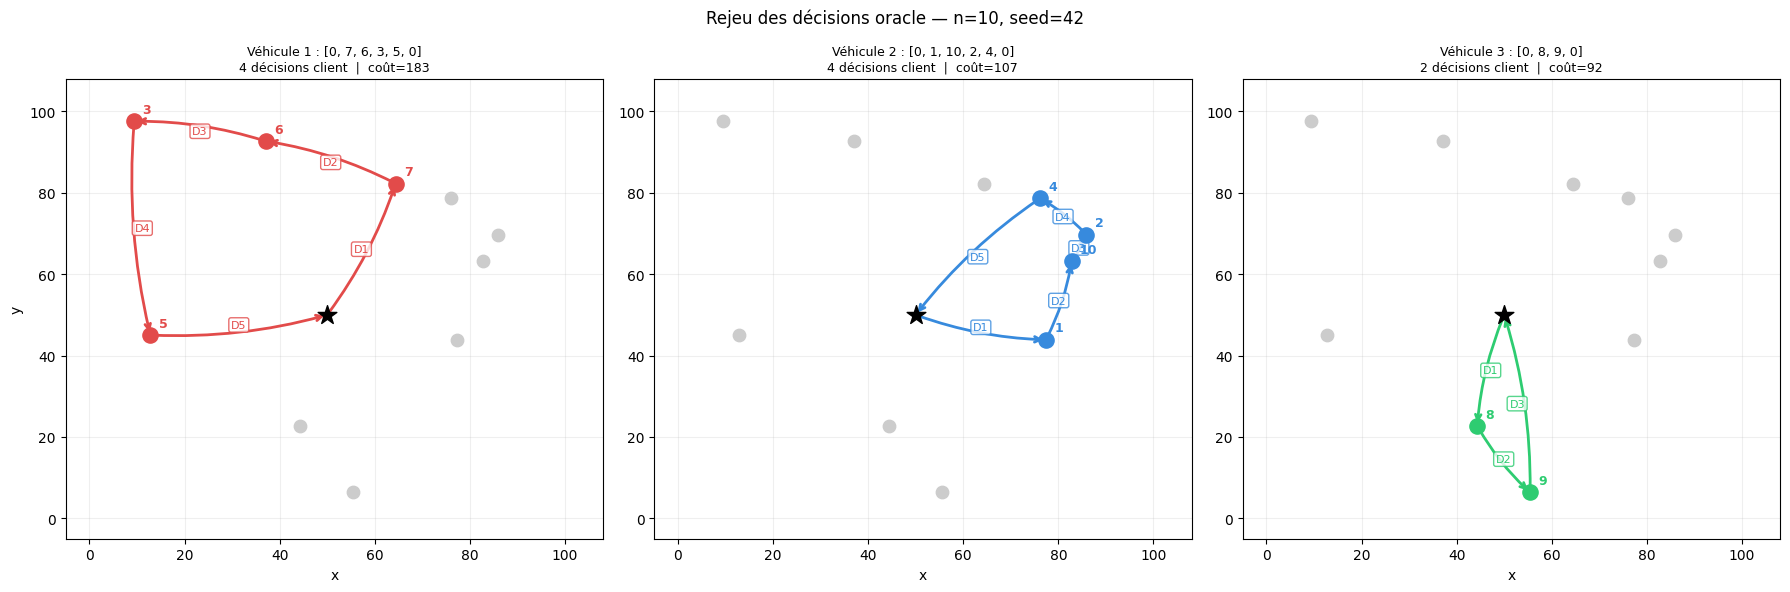

D1, D2, ... = numéros de décision capturés dans le dataset


In [25]:
coords  = instance['coords']
palette = ['#E24B4A', '#378ADD', '#2ECC71']
routes  = [r for r in sol['tournees'] if r]

fig, axes = plt.subplots(1, len(routes), figsize=(6 * len(routes), 6))
if len(routes) == 1:
    axes = [axes]

fig.suptitle(f'Rejeu des décisions oracle — n={N}, seed={SEED}', fontsize=12)

for v_idx, (route, ax) in enumerate(zip(routes, axes)):
    color  = palette[v_idx % len(palette)]
    chemin = [0] + route + [0]

    # Fond : tous les clients en gris
    ax.scatter(coords[1:, 0], coords[1:, 1], c='#CCCCCC', s=80, zorder=2)
    ax.scatter(coords[0, 0], coords[0, 1], c='black', s=200, marker='*', zorder=5)

    # Tracer la route avec numéros de décision
    for step, (a, b) in enumerate(zip(chemin[:-1], chemin[1:])):
        ax.annotate('', xy=coords[b], xytext=coords[a],
                    arrowprops=dict(arrowstyle='->', color=color, lw=2,
                                   connectionstyle='arc3,rad=0.08'))
        mid_x = (coords[a, 0] + coords[b, 0]) / 2
        mid_y = (coords[a, 1] + coords[b, 1]) / 2
        ax.text(mid_x, mid_y, f'D{step+1}', fontsize=8, color=color,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))

    # Clients de cette route
    ax.scatter(coords[route, 0], coords[route, 1], c=color, s=120, zorder=4)
    for c_idx in route:
        ax.annotate(f'{c_idx}', xy=coords[c_idx], xytext=(6, 6),
                    textcoords='offset points', fontsize=9, color=color, fontweight='bold')

    cout_r = sum(instance['dist'][chemin[k], chemin[k+1]] for k in range(len(chemin)-1))
    ax.set_title(f'Véhicule {v_idx+1} : {chemin}\n{len(route)} décisions client  |  coût={cout_r:.0f}', fontsize=9)
    ax.set_xlim(-5, 108)
    ax.set_ylim(-5, 108)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('x')
    if v_idx == 0:
        ax.set_ylabel('y')

plt.tight_layout()
plt.show()
print("D1, D2, ... = numéros de décision capturés dans le dataset")

## 8. Pourquoi mixer n=10 et n=20 ?

Le dataset mixte pondère **n10 × 2 + n20 × 1** pour deux raisons :

1. **Rééquilibrage** : n=20 produit ~2× plus de décisions par instance que n=10 (20 clients vs 10). Sans pondération, le modèle verrait 2× plus d'exemples n=20.

2. **Généralisation** : entraîner sur des tailles variées force le modèle à apprendre des stratégies **indépendantes de la taille** plutôt que de mémoriser les patterns d'une taille fixe.

Le padding dans `collate_decisions()` gère la variabilité de taille dans les batchs PyTorch.

Répartition des décisions dans le dataset mixte :
  n=10 :  19920 décisions  ███████████████████████████████████████████████████████████████████████████████████████████████████  (50.6%)
  n=20 :  19480 décisions  █████████████████████████████████████████████████████████████████████████████████████████████████  (49.4%)


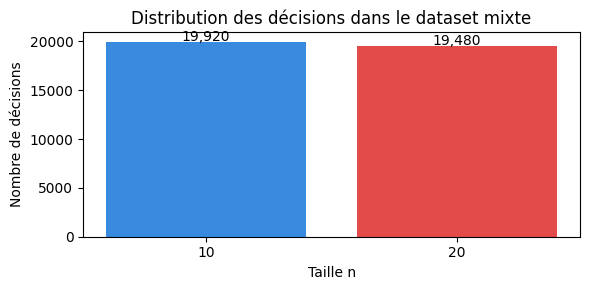

In [26]:
# Visualiser la distribution des tailles dans le dataset mixte
sizes = np.array([ex['n'] for ex in dataset])

unique, counts = np.unique(sizes, return_counts=True)
print("Répartition des décisions dans le dataset mixte :")
for n_val, cnt in zip(unique, counts):
    bar = '█' * (cnt // 200)
    print(f"  n={n_val:>2} : {cnt:>6} décisions  {bar}  ({cnt/len(sizes):.1%})")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([str(n) for n in unique], counts, color=['#378ADD', '#E24B4A'])
ax.set_xlabel('Taille n')
ax.set_ylabel('Nombre de décisions')
ax.set_title('Distribution des décisions dans le dataset mixte')
for i, (n_val, cnt) in enumerate(zip(unique, counts)):
    ax.text(i, cnt + 100, f'{cnt:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Récapitulatif

```
resoudre_instance()  →  tournées oracle : [[3,1,7], [4,6], [2,5,8,9,10]]
         ↓
extract_decision_examples()  →  rejoue chaque route pas à pas
         ↓
Pour chaque étape :
  ┌─────────────────────────────────────────────────────┐
  │  node_features   (N, 7)  ← statique (une fois/inst) │
  │  action_features (N, 5)  ← dynamique (par décision) │
  │  feasible_mask   (N,)    ← qui peut-on visiter ?     │
  │  dynamic_global  (6,)    ← état global              │
  │  target_next_node  int   ← LABEL oracle             │
  └─────────────────────────────────────────────────────┘
         ↓
39 400 exemples  →  Section 4 : entraînement du modèle
```